# Programmation Python — Séance 8 : Visualiser et faire le pont
**DMI · FST · UCAD**

Dernière séance. Un tableau de chiffres ne montre pas la **forme** des données ; un **graphique**, si. On travaille sur un jeu très concret — des **fruits du marché** (mangues, bananes, oranges), pesés et mesurés — puis on fait le **pont vers le Machine Learning**.

**Comment travailler.** Exécutez chaque cellule avec **Maj + Entrée**. Les cellules **À vous** sont à compléter : c'est là que vous apprenez. Elles vont de la simple répétition à l'analyse complète, et la dernière section est un **exercice de synthèse** où vous menez l'analyse de bout en bout.

**Rappel des trois graphiques :**
| La question | Le graphique | La fonction |
|---|---|---|
| Comment se répartit une mesure ? | histogramme | `plt.hist` |
| Quel groupe a la plus grande valeur ? | barres | `plt.bar` |
| Deux mesures sont-elles liées ? | nuage de points | `plt.scatter` |


***
## 1. Le jeu de données

30 fruits : 10 mangues, 10 bananes, 10 oranges. Pour chacun, la **masse** (g), la **longueur** (cm) et le **taux de sucre** (%).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "fruit": ["mangue"]*10 + ["banane"]*10 + ["orange"]*10,
    "masse": [301, 313, 277, 283, 272, 329, 321, 326, 310, 312,
              137, 117, 120, 122, 119, 114, 126, 106, 114, 115,
              201, 223, 206, 210, 196, 205, 197, 177, 230, 198],
    "longueur": [10.3, 12.1, 10.3, 10.6, 10.8, 10.5, 11.5, 10.9, 11.0, 10.9,
                 18.4, 19.1, 19.1, 19.0, 18.9, 19.3, 20.0, 19.6, 17.1, 19.7,
                 8.1, 8.8, 8.1, 8.1, 8.3, 7.3, 8.9, 8.2, 7.6, 8.6],
    "sucre": [14.7, 13.7, 13.9, 14.2, 13.2, 13.8, 14.3, 14.6, 14.1, 13.7,
              11.1, 11.1, 12.1, 11.3, 12.8, 12.3, 11.6, 11.2, 12.2, 12.6,
              9.2, 8.5, 9.1, 9.0, 9.2, 9.2, 9.4, 8.4, 9.0, 8.5],
}
df = pd.DataFrame(data)
print(df.shape)
print(df.head())

(30, 4)
    fruit  masse  longueur  sucre
0  mangue    301      10.3   14.7
1  mangue    313      12.1   13.7
2  mangue    277      10.3   13.9
3  mangue    283      10.6   14.2
4  mangue    272      10.8   13.2

In [2]:
print(df["fruit"].value_counts())

fruit
mangue    10
banane    10
orange    10
Name: count, dtype: int64

Un coup d'oeil aux masses : la plus petite, la plus grande, la moyenne.

In [3]:
print(df["masse"].min())
print(df["masse"].max())
print(df["masse"].mean().round(1))

106
329
209.2

**À vous (A).** Affichez la longueur **minimale** et la longueur **maximale** de la table.

In [ ]:
# À vous : affichez df["longueur"].min() et df["longueur"].max()

**À vous (B).** Affichez le résumé statistique des mesures avec `df.describe().round(2)`.

In [ ]:
# À vous : affichez df.describe().round(2)

***
## 2. L'histogramme : comment se répartit une mesure

Un **histogramme** découpe l'axe en tranches et compte combien de fruits tombent dans chacune. On légende toujours : `xlabel`, `ylabel`, `title`.

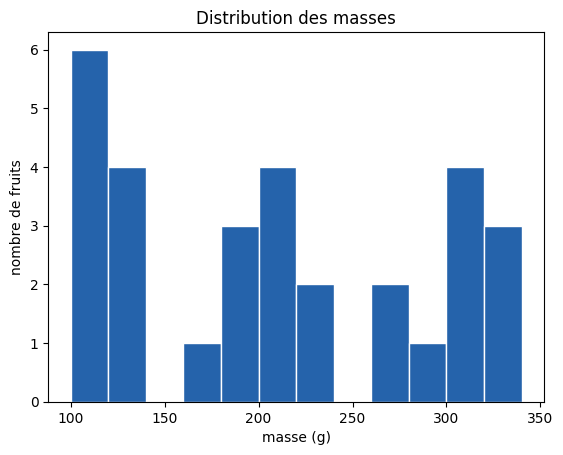

In [4]:
plt.hist(df["masse"], bins=range(100, 360, 20), color="#2563AB", edgecolor="white")
plt.xlabel("masse (g)")
plt.ylabel("nombre de fruits")
plt.title("Distribution des masses")

Trois amas apparaissent : autour de 120 g, de 200 g et de 300 g. Ce sont les bananes, les oranges et les mangues — le tableau de chiffres ne le montrait pas aussi vite.

L'argument `bins` fixe les **tranches** : ici, une barre tous les 20 g. Des tranches plus fines montrent plus de detail, au risque du bruit.

**À vous (1).** Tracez l'histogramme de la colonne `sucre`, avec un titre et des axes légendés.

In [ ]:
# À vous : plt.hist(df["sucre"], ...) avec xlabel, ylabel, title

**À vous (2).** Tracez l'histogramme de la colonne `longueur`. Combien d'amas voyez-vous ? Écrivez votre réponse en commentaire dans la cellule.

In [ ]:
# À vous : histogramme de longueur, puis en commentaire : combien d'amas ?

**À vous (3).** Reprenez l'histogramme des masses avec des tranches **plus larges** : `bins=range(100, 360, 60)`. Les trois amas sont-ils encore visibles ?

In [ ]:
# À vous : plt.hist(df["masse"], bins=range(100, 360, 60)) puis legendes

***
## 3. Le diagramme en barres : comparer les groupes

Pour comparer une valeur **par fruit**, on part d'un `groupby` (Séance 7), puis on trace des barres.

In [5]:
masse_moy = df.groupby("fruit")["masse"].mean().round(1)
print(masse_moy)

fruit
banane    119.0
mangue    304.4
orange    204.3
Name: masse, dtype: float64

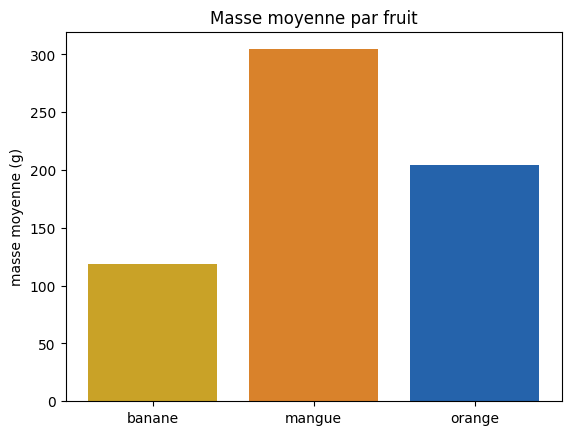

In [6]:
masse_moy = df.groupby("fruit")["masse"].mean()
plt.bar(masse_moy.index, masse_moy.values, color=["#C9A227", "#D9822B", "#2563AB"])
plt.ylabel("masse moyenne (g)")
plt.title("Masse moyenne par fruit")

Une mangue pèse en moyenne 304 g, une orange 204 g, une banane 119 g. Le graphique rend la comparaison immédiate.

Meme principe pour n'importe quelle mesure. Avec la longueur moyenne :

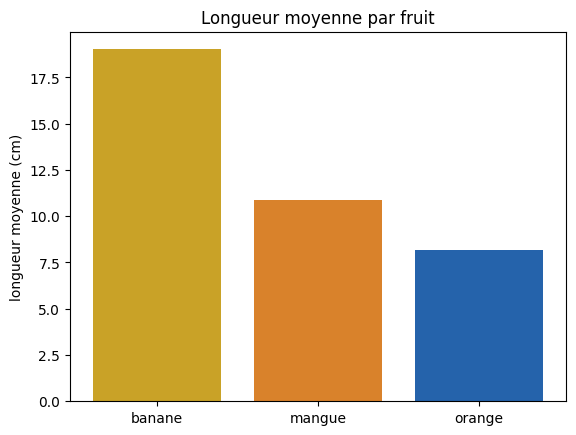

In [7]:
long_moy = df.groupby("fruit")["longueur"].mean()
plt.bar(long_moy.index, long_moy.values, color=["#C9A227", "#D9822B", "#2563AB"])
plt.ylabel("longueur moyenne (cm)")
plt.title("Longueur moyenne par fruit")

La banane se detache nettement : c'est le fruit le plus long du panier.

**À vous (4).** Tracez un diagramme en barres du **taux de sucre moyen** par fruit (calculez d'abord `df.groupby("fruit")["sucre"].mean()`).

In [ ]:
# À vous : barres de df.groupby("fruit")["sucre"].mean()

**À vous (5).** Tracez un diagramme en barres de la masse **maximale** par fruit (`.max()` au lieu de `.mean()`). Comparez avec le graphique des moyennes : les fruits gardent-ils le même ordre ?

In [ ]:
# À vous : barres de df.groupby("fruit")["masse"].max()

***
## 4. Le nuage de points : deux mesures à la fois

Le **nuage de points** (`scatter`) place chaque fruit selon **deux** mesures. En **colorant par fruit**, les groupes apparaissent. On trace une couche par fruit, avec sa couleur et son `label`.

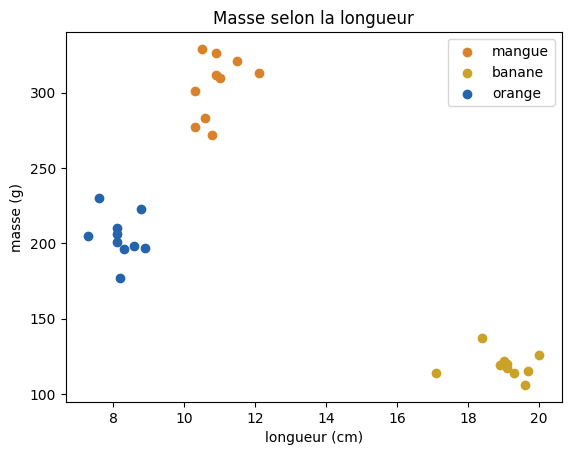

In [8]:
couleurs = {"mangue": "#D9822B", "banane": "#C9A227", "orange": "#2563AB"}
for nom, coul in couleurs.items():
    sous = df[df["fruit"] == nom]
    plt.scatter(sous["longueur"], sous["masse"], c=coul, label=nom)
plt.xlabel("longueur (cm)")
plt.ylabel("masse (g)")
plt.title("Masse selon la longueur")
plt.legend()

**Trois amas nettement séparés.** La banane est longue et légère ; la mangue, courte et lourde ; l'orange, courte et moyenne. Avec ces deux mesures, on reconnaît le fruit **sans le voir** — c'est exactement l'idée du Machine Learning.

**À vous (6).** Tracez un nuage de points de `sucre` (axe des x) contre `masse` (axe des y), coloré par fruit, avec une légende.

In [ ]:
# À vous : scatter de sucre (x) contre masse (y), colore par fruit, avec legende

**À vous (7).** Tracez le nuage `longueur` contre `sucre`, coloré par fruit. Les trois groupes sont-ils aussi bien séparés qu'avec `longueur` et `masse` ? Répondez en commentaire.

In [ ]:
# À vous : scatter de longueur (x) contre sucre (y), colore par fruit

**À vous (8).** Sans couleur cette fois : tracez `longueur` contre `masse` en un seul `plt.scatter`, sans boucle. Voit-on encore quel groupe est quel fruit ?

In [ ]:
# À vous : plt.scatter(df["longueur"], df["masse"]) puis legendes des axes

***
## 5. Une mini-analyse exploratoire

L'**analyse exploratoire** (EDA) enchaîne toujours les mêmes gestes : **charger**, **décrire**, **tracer**, **observer**. Le profil moyen de chaque fruit résume la table.

In [9]:
print(df.groupby("fruit")[["masse", "longueur", "sucre"]].mean().round(1))

        masse  longueur  sucre
fruit                         
banane  119.0      19.0   11.8
mangue  304.4      10.9   14.0
orange  204.3       8.2    9.0

On **observe** : la mangue est la plus lourde et la plus sucrée ; la banane est la plus longue ; l'orange est la moins sucrée. Chaque mesure aide à distinguer les fruits.

**À vous (9).** Affichez la masse **maximale** par fruit avec `df.groupby("fruit")["masse"].max()`.

In [ ]:
# À vous : affichez df.groupby("fruit")["masse"].max()

**À vous (10).** Un client veut le fruit le plus sucré. Affichez le **taux de sucre moyen par fruit**, trié du plus sucré au moins sucré (`.sort_values(ascending=False)`).

In [ ]:
# À vous : df.groupby("fruit")["sucre"].mean().sort_values(ascending=False)

**À vous (11).** Combien de fruits pèsent plus de 250 g ? Utilisez un filtre (Séance 7) puis `len(...)`.

In [ ]:
# À vous : len(df[df["masse"] > 250])

***
## 6. Le pont vers le Machine Learning

Reconnaître le fruit à partir de ses mesures, c'est le travail d'un modèle. On lui présente deux objets : une **matrice `X`** (les mesures, un fruit par ligne) et un **vecteur `y`** (ce qu'on veut prédire, ici le nom du fruit).

In [10]:
X = df[["masse", "longueur", "sucre"]].values
y = df["fruit"].values
print("X shape :", X.shape)
print("y shape :", y.shape)
print("premier fruit  X[0] :", X[0])
print("son nom        y[0] :", y[0])

X shape : (30, 3)
y shape : (30,)
premier fruit  X[0] : [301.   10.3  14.7]
son nom        y[0] : mangue

`X` a la forme `(30, 3)` : 30 fruits, 3 mesures. `y` a la forme `(30,)` : un nom par fruit. C'est **exactement** ce qu'attend une bibliothèque de Machine Learning comme scikit-learn. Le code ci-dessous n'est pas exécuté ici (il appartient au cours de ML) ; il montre la suite :

```python
from sklearn.tree import DecisionTreeClassifier

modele = DecisionTreeClassifier()
modele.fit(X, y)          # le modele APPREND le lien X -> y
modele.predict([[300, 11, 14]])   # un fruit de 300 g, 11 cm, 14 % : mangue ?
```

Deux méthodes suffisent : **`fit`** pour apprendre, **`predict`** pour prédire.

Les trois premieres lignes de `X` : un fruit par ligne, trois mesures par colonne.

In [11]:
print(X[:3])

[[301.   10.3  14.7]
 [313.   12.1  13.7]
 [277.   10.3  13.9]]

**À vous (12).** Construisez une matrice `X2` ne contenant que `masse` et `longueur`, puis affichez sa forme avec `X2.shape`.

In [ ]:
# À vous : X2 = df[["masse", "longueur"]].values, puis affichez X2.shape

**À vous (13).** Construisez le vecteur `y2 = df["fruit"].values` et affichez ses 5 premières valeurs avec `y2[:5]`.

In [ ]:
# À vous : y2 = df["fruit"].values, puis affichez y2[:5]

**À vous (14).** Vérifiez que `X` et `y` ont bien **le même nombre de lignes** : affichez `X.shape[0] == y.shape[0]`. Pourquoi est-ce indispensable ?

In [ ]:
# À vous : affichez X.shape[0] == y.shape[0]

***
## 7. Exercice de synthèse : une analyse de bout en bout

Un maraîcher vous confie un **nouveau relevé** : 18 fruits, avec les mêmes mesures. À vous de mener l'analyse **seul**, en suivant les quatre gestes de l'EDA : **charger → décrire → tracer → observer**.

In [12]:
panier = pd.DataFrame({
    "fruit": ["mangue"]*6 + ["banane"]*6 + ["orange"]*6,
    "masse": [295, 318, 288, 306, 299, 324,
              128, 115, 121, 109, 133, 118,
              212, 195, 208, 221, 187, 203],
    "longueur": [11.2, 10.6, 10.9, 11.4, 10.2, 11.8,
                 18.7, 19.4, 18.2, 20.1, 17.9, 19.0,
                 8.4, 7.9, 8.7, 8.0, 8.9, 8.2],
    "sucre": [13.9, 14.4, 13.5, 14.8, 13.2, 14.1,
              12.4, 11.7, 12.9, 11.2, 12.1, 11.9,
              9.3, 8.7, 9.6, 8.9, 9.1, 8.4],
})
print(panier.shape)

(18, 4)

**Synthèse 1 — Charger.** Affichez les 5 premières lignes de `panier`, puis le nombre de fruits de chaque type.

In [ ]:
# À vous : panier.head() puis panier["fruit"].value_counts()

**Synthèse 2 — Décrire.** Affichez le résumé statistique des mesures, arrondi à 2 décimales.

In [ ]:
# À vous : panier.describe().round(2)

**Synthèse 3 — Décrire.** Affichez le profil moyen de chaque fruit (les trois mesures d'un coup, arrondies à 1 décimale).

In [ ]:
# À vous : panier.groupby("fruit")[["masse", "longueur", "sucre"]].mean().round(1)

**Synthèse 4 — Tracer.** Tracez l'histogramme des masses de `panier`. Retrouve-t-on les trois amas ?

In [ ]:
# À vous : histogramme des masses de panier, avec les trois legendes

**Synthèse 5 — Tracer.** Tracez le diagramme en barres de la **longueur moyenne** par fruit.

In [ ]:
# À vous : barres de panier.groupby("fruit")["longueur"].mean()

**Synthèse 6 — Tracer.** Tracez le nuage `longueur` contre `masse`, coloré par fruit, avec une légende.

In [ ]:
# À vous : scatter longueur (x) contre masse (y), colore par fruit

**Synthèse 7 — Observer.** En **trois phrases**, dans la cellule markdown ci-dessous, décrivez ce que vous avez compris de ce panier : la forme des masses, le fruit le plus long, et si les groupes sont séparables.

*(Écrivez votre réponse ici — double-cliquez sur cette cellule pour l'éditer.)*

1. 
2. 
3. 

**Synthèse 8 — Le pont ML.** Construisez `X_panier` (les trois mesures) et `y_panier` (le fruit), puis affichez leurs formes.

In [ ]:
# À vous : X_panier = ..., y_panier = ..., puis affichez les deux shapes

***
## 8. Pièges fréquents

- **Un graphique sans légende est illisible** : toujours `xlabel`, `ylabel`, `title` (et `legend()` s'il y a des groupes).
- **Colorer par catégorie demande une boucle** : une couche `scatter` par fruit, chacune avec sa couleur et son `label`.
- **`.values`** transforme des colonnes en **tableau NumPy** : le format attendu pour `X` et `y`.
- **La forme compte** : `X` est `(n_fruits, n_mesures)`, `y` est `(n_fruits,)`.

***
## Récapitulatif — et bilan du cours

- **Visualiser** : `plt.hist` (répartition), `plt.bar` (comparer des groupes), `plt.scatter` (deux mesures, coloré par catégorie) ; toujours légender.
- **Mini-EDA** : charger → décrire → tracer → observer.
- **Pont ML** : la table devient `X` (les mesures) et `y` (à prédire) ; un modèle s'utilise avec `fit` puis `predict`.

**Bilan du cours.** Des valeurs et des types (S1) aux structures (S2), au contrôle du flux (S3), aux fonctions (S4), aux objets (S5), puis à NumPy (S6), pandas (S7) et à la visualisation (S8) : vous savez désormais **charger, explorer et préparer des données** — et vous êtes prêts pour le **Machine Learning**.